# Finding a Hamiltonian's ground state with a tiny GPT

In this notebook we're going to build **nano GQE** from scratch. GQE (generative quantum eigensolver) is a surprisingly simple idea: train a small transformer whose vocabulary is quantum gates. Every sequence the model writes is a circuit. We run the circuit, see how low its energy is on some Hamiltonian \(H\), and use GRPO to make the model write more circuits like the good ones.

I'm going to rebuild the whole loop **inline** (PennyLane + JAX) so you can see every piece, and then at the end we'll check the diagonal case against the `gqe` package to make sure we're not fooling ourselves. Two problems, both small enough for an M4 MacBook CPU:

| Part | Hamiltonian | Qubits | Reward | What "the answer" is |
|---|---|---|---|---|
| 1 | Random SK spin glass (diagonal) | 8 | CVaR of measured bitstrings | The lowest-energy bitstring ever measured |
| 2 | Any Pauli-sum \(H\) (default: TFIM) | 6 | Exact \(\langle\psi\|H\|\psi\rangle\) | The circuit whose state is closest to the ground state |

Each training cell should finish in under two minutes. The model is ~5k parameters, which is tiny. That's on purpose.

## 0. Setup

Boring but important. Force JAX onto the CPU, use float64 for the circuit numerics (so that later the reference vs. fast-path check can demand agreement to \(10^{-10}\)), and pin a seed.

In [13]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/gqe-mpl")

from dataclasses import dataclass
from functools import partial
from typing import Callable

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pennylane as qml

SEED = 0
rng = np.random.default_rng(SEED)
key = jax.random.PRNGKey(SEED)

plt.rcParams.update({"figure.figsize": (7.2, 3.3), "axes.grid": True, "grid.alpha": 0.3})

print(f"JAX {jax.__version__} on {jax.default_backend()}  |  PennyLane {qml.__version__}")


JAX 0.7.1 on cpu  |  PennyLane 0.45.1


### The loop, in one picture

Before any code, here's the entire algorithm:

1. The transformer samples a **group** of token sequences (each token = one fixed-angle gate).
2. Each sequence is a circuit on \(n\) qubits. We either measure it or read off \(\lvert\psi\rangle\) exactly.
3. A scalar **score** (lower = better) comes from those shots, or from \(\langle H\rangle\).
4. GRPO ranks the group, then takes a clipped policy-gradient step on the token log-probs.

That's it. Notice that nothing here is specific to molecules, QUBO, or Ising. Only the **pool** (the vocabulary) and the **score** change from problem to problem. Everything else is the same.

## 1. The problem is a Hamiltonian

Basically every electronic-structure, spin, or QUBO problem we care about can be written as a Hermitian operator, a **Pauli sum**:

\[
H = \sum_k c_k P_k, \qquad P_k \in \{I,X,Y,Z\}^{\otimes n}.
\]

PennyLane stores this as `qml.Hamiltonian(coeffs, ops)`. At \(n \lesssim 12\) we can cheat: the exact ground energy \(E_0\) and ground state \(\lvert\psi_0\rangle\) are just one dense diagonalization of a \(2^n \times 2^n\) matrix. That's totally fine for a notebook, and it gives us the label to plot against. Always have a label.

In [14]:
def exact_eigensystem(H, n):
    # Column evecs[:, 0] is the ground state; wire 0 = MSB.
    mat = np.asarray(qml.matrix(H, wire_order=range(n)), dtype=np.complex128)
    evals, evecs = np.linalg.eigh(mat)
    return evals.real, evecs


def bits_of(index, n):
    return format(int(index), f"0{n}b")


def z_product(wires):
    op = qml.Z(wires[0])
    for w in wires[1:]:
        op = op @ qml.Z(w)
    return op


### Diagonal vs. off-diagonal

This distinction matters a lot, so let's be careful. If every \(P_k\) is made only of \(Z\) (and \(I\)), then \(H\) is **diagonal** in the computational basis. That means:

- every computational-basis vector \(\lvert b\rangle\) is an eigenvector,
- a single shot *is* an energy,
- the ground state is a bitstring (or a handful of degenerate bitstrings).

QUBO / Ising / MaxCut all live here. But the moment \(H\) picks up an \(X\) or a \(Y\), the ground state is generally entangled, shots in the \(Z\) basis are no longer eigenstates, and "the best bitstring I measured" stops being the answer.

Four qubits is enough to see the difference with your own eyes. Left: a tiny SK spin glass. Right: a transverse-field Ising chain at \(g=1\).

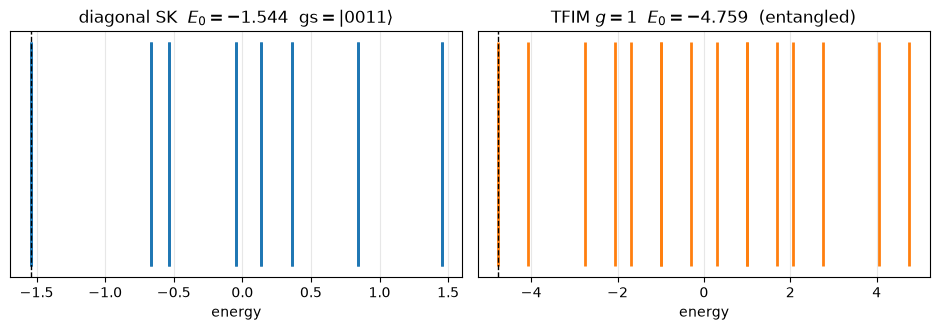

TFIM ground-state weight on computational basis (sorted):
  |0000>  p=0.230
  |1111>  p=0.230
  |1000>  p=0.065
  |0001>  p=0.065
  |1110>  p=0.065
  |0111>  p=0.065
SK ground state is essentially |0011>  (p=1.000000)


In [15]:
from gqe.ising import random_sk

n_toy = 4
sk_toy = random_sk(n_toy, seed=0)
H_diag = sk_toy.hamiltonian()
evals_d, evecs_d = exact_eigensystem(H_diag, n_toy)
gs_bits = bits_of(int(np.argmax(np.abs(evecs_d[:, 0]) ** 2)), n_toy)

H_tfim_toy = qml.Hamiltonian(
    [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
    [qml.Z(0) @ qml.Z(1), qml.Z(1) @ qml.Z(2), qml.Z(2) @ qml.Z(3),
     qml.X(0), qml.X(1), qml.X(2), qml.X(3)],
)
evals_t, evecs_t = exact_eigensystem(H_tfim_toy, n_toy)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].vlines(evals_d, 0, 1, colors="C0", linewidth=2)
axes[0].set_title(f"diagonal SK  $E_0={evals_d[0]:.3f}$  gs$=\\vert{gs_bits}\\rangle$")
axes[1].vlines(evals_t, 0, 1, colors="C1", linewidth=2)
axes[1].set_title(f"TFIM $g=1$  $E_0={evals_t[0]:.3f}$  (entangled)")
for ax in axes:
    ax.set_xlabel("energy")
    ax.set_yticks([])
    ax.axvline(evals_d[0] if ax is axes[0] else evals_t[0], color="k", ls="--", lw=1)
plt.tight_layout()
plt.show()

amp = np.abs(evecs_t[:, 0]) ** 2
print("TFIM ground-state weight on computational basis (sorted):")
for i in np.argsort(-amp)[:6]:
    print(f"  |{bits_of(i, n_toy)}>  p={amp[i]:.3f}")
print(f"SK ground state is essentially |{gs_bits}>  (p={np.abs(evecs_d[int(gs_bits, 2), 0])**2:.6f})")


## 2. The gate vocabulary

Here's a constraint that shapes everything: the transformer can't emit a continuous angle. It picks tokens. So every token is one **fixed-angle** gate, and the vocabulary (we'll call it the **pool**) is just a list of those gates. We'll use two pools in this notebook.

**Diagonal / QAOA-style** (same as `gqe.ising.build_pool`):

- cost layer \(e^{-i\gamma H/\lVert H\rVert}\) for \(\gamma \in \{0.1, 0.2, 0.4, 0.8\}\)
- mixer \(e^{-i\beta \sum_i X_i}\) for \(\beta \in \{\pm 0.1, \pm 0.2, \pm 0.4\}\)
- local bias \(\mathrm{RY}(\pm\pi/4)\) on each qubit

Any discrete-angle QAOA circuit of depth \(\le\) `seq_len/2` is one particular sequence in this vocabulary. The model is free to do something else: pick a different depth, mix up the angles, insert local tweaks.

**General / GQE operator pool:** for each Pauli term \(P_k\) in \(H\), add \(\mathrm{PauliRot}(\theta, P_k)\) at \(\theta \in \{\pm\pi/16, \pm\pi/4\}\), plus the same RY biases. We use this one when \(H\) isn't diagonal.

In [16]:
@dataclass(frozen=True)
class Token:
    label: str
    apply: Callable[[], None]


GAMMAS = (0.1, 0.2, 0.4, 0.8)
BETAS = (-0.4, -0.2, -0.1, 0.1, 0.2, 0.4)
LOCAL = (-np.pi / 4, np.pi / 4)
PAULI_ANGLES = (-np.pi / 4, -np.pi / 16, np.pi / 16, np.pi / 4)


def _zphase(terms, gamma):
    def apply():
        for wires, c in terms:
            if len(wires) == 1:
                qml.RZ(2.0 * c * gamma, wires=wires[0])
            else:
                qml.IsingZZ(2.0 * c * gamma, wires=list(wires))

    return apply


def _xmix(n, beta):
    def apply():
        for w in range(n):
            qml.RX(2.0 * beta, wires=w)

    return apply


def diagonal_pool(model) -> list[Token]:
    # Cost layers, mixers, local RY. Same layout as gqe.ising.build_pool.
    scale = max(np.abs(model.h).max(initial=0.0), np.abs(model.J).max(initial=0.0)) or 1.0
    terms = tuple(((int(i),), float(model.h[i] / scale)) for i in np.flatnonzero(model.h)) + tuple(
        ((i, j), float(model.J[i, j] / scale)) for i, j in model.edges
    )
    pool = [Token("I", lambda: None)]
    pool += [Token(f"C({g:.2f})", _zphase(terms, g)) for g in GAMMAS]
    pool += [Token(f"M({b:+.2f})", _xmix(model.n, b)) for b in BETAS]
    for a in LOCAL:
        for i in range(model.n):
            pool.append(Token(f"Y{i}({a:+.2f})", lambda i=i, a=a: qml.RY(a, wires=i)))
    return pool


def pauli_word_and_wires(op):
    # Map a PennyLane Pauli product to the (word, wires) that qml.PauliRot expects.
    if op.pauli_rep is None:
        raise ValueError(f"non-Pauli operator {op}")
    items = list(op.pauli_rep.items())
    if len(items) != 1:
        raise ValueError(f"expected a single Pauli word, got {op}")
    pw, _ = items[0]
    if len(pw) == 0:
        return None  # identity: constant shift, not a gate
    wires = sorted(int(w) for w in pw.keys())
    word = "".join(str(pw[w]) for w in wires)
    return word, wires


def operator_pool(H, n) -> list[Token]:
    # GQE-style pool: PauliRot on each term of H, plus local RY.
    pool = [Token("I", lambda: None)]
    seen: set[tuple] = set()
    for op in H.ops:
        parsed = pauli_word_and_wires(op)
        if parsed is None:
            continue
        word, wires = parsed
        key = (word, tuple(wires))
        if key in seen:
            continue
        seen.add(key)
        for theta in PAULI_ANGLES:
            pool.append(
                Token(
                    f"R{word}{list(wires)}({theta:+.3f})",
                    lambda word=word, wires=wires, theta=theta: qml.PauliRot(theta, word, wires=wires),
                )
            )
    for a in LOCAL:
        for i in range(n):
            pool.append(Token(f"Y{i}({a:+.2f})", lambda i=i, a=a: qml.RY(a, wires=i)))
    return pool


pool_toy = diagonal_pool(sk_toy)
print(f"4-qubit SK diagonal pool: {len(pool_toy)} tokens")
print(" ", ", ".join(t.label for t in pool_toy[:12]), "...")


4-qubit SK diagonal pool: 19 tokens
  I, C(0.10), C(0.20), C(0.40), C(0.80), M(-0.40), M(-0.20), M(-0.10), M(+0.10), M(+0.20), M(+0.40), Y0(-0.79) ...


Let's look at one. Here's a random 6-token circuit on the 4-qubit toy, drawn by PennyLane. Cost layers expand into every \(ZZ\) coupling; mixers are a row of \(\mathrm{RX}\).

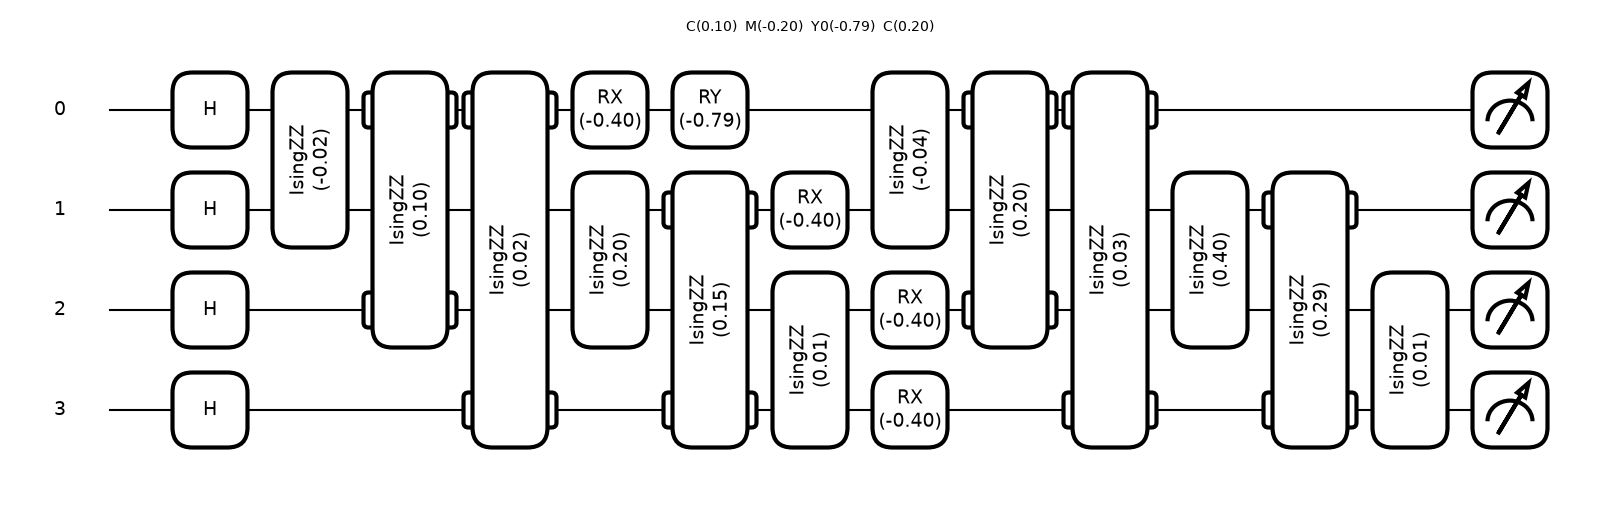

In [17]:
def draw_sequence(n, pool, token_ids, init="plus"):
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def circ():
        if init == "plus":
            for w in range(n):
                qml.Hadamard(wires=w)
        for t in token_ids:
            pool[int(t)].apply()
        return qml.probs(wires=range(n))

    fig, _ax = qml.draw_mpl(circ, decimals=2, style="black_white")()
    fig.suptitle("  ".join(pool[int(t)].label for t in token_ids), fontsize=10)
    return fig


demo_ids = [1, 6, 11, 2]  # C(0.10), a mixer, a local RY, C(0.20)
draw_sequence(n_toy, pool_toy, demo_ids, init="plus")
plt.show()


## 3. Running a token sequence

We need a function \(\text{tokens} \mapsto \lvert\psi\rangle\). I'm going to write it twice.

**Reference (the obviously-correct version).** A `default.qubit` QNode applies each token in order and returns `qml.state()`. It's slow if you call it thousands of times, but it's the definition of correctness, so we keep it around.

**Fast path.** Each token is a fixed unitary, so precompute \(U_v = \texttt{qml.matrix}(\text{token } v)\) once (\(256\times 256\) at \(n=8\), \(64\times 64\) at \(n=6\)). Now a circuit is just a `jax.lax.scan` of matrix–vector products, JIT-compiled. This is what the training loop actually calls.

(The package, `gqe.circuit`, does a third thing: Catalyst `@qjit` compiles **one** program per sequence length whose *input* is the token ids. That stays exact once \(2^n\) is too big for a dense matrix. Here \(n\le 8\), so storing the unitaries is simpler and plenty fast.)

In [18]:
def make_reference(n, pool, init: str):
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev, interface="numpy")
    def state(token_ids):
        if init == "plus":
            for w in range(n):
                qml.Hadamard(wires=w)
        for t in np.asarray(token_ids).tolist():
            pool[int(t)].apply()
        return qml.state()

    return state


def compile_unitaries(n, pool):
    mats = []
    for tok in pool:
        def qf(fn=tok.apply):
            fn()

        mats.append(np.asarray(qml.matrix(qf, wire_order=range(n))(), dtype=np.complex128))
    return jnp.asarray(np.stack(mats))


def initial_statevector(n, init: str):
    dim = 2**n
    psi = np.zeros(dim, dtype=np.complex128)
    if init == "zero":
        psi[0] = 1.0
    else:
        psi[:] = 1.0 / np.sqrt(dim)
    return jnp.asarray(psi)


@jax.jit
def apply_tokens(token_ids, unitaries, psi0):
    # token_ids (L,) -> |psi>. Empty sequence returns psi0.

    def step(psi, t):
        return unitaries[t] @ psi, None

    psi, _ = jax.lax.scan(step, psi0, token_ids)
    return psi


@jax.jit
def apply_tokens_batch(tokens, unitaries, psi0):
    return jax.vmap(lambda seq: apply_tokens(seq, unitaries, psi0))(tokens)


Never trust a fast path you haven't checked. On random sequences of the 4-qubit toy: \(\lVert\psi_{\text{fast}} - \psi_{\text{ref}}\rVert_\infty < 10^{-10}\).

In [19]:
Us_toy = compile_unitaries(n_toy, pool_toy)
psi0_toy = initial_statevector(n_toy, "plus")
ref_toy = make_reference(n_toy, pool_toy, "plus")

max_err = 0.0
for length in (0, 1, 6):
    for _ in range(4):
        seq = rng.integers(0, len(pool_toy), size=length).astype(np.int32)
        psi_fast = np.asarray(apply_tokens(jnp.asarray(seq), Us_toy, psi0_toy))
        psi_ref = np.asarray(ref_toy(seq))
        err = np.max(np.abs(psi_fast - psi_ref))
        max_err = max(max_err, err)

print(f"max |ψ_fast − ψ_ref| = {max_err:.3e}")
assert max_err < 1e-10, max_err
print("fast path matches default.qubit")


max |ψ_fast − ψ_ref| = 3.421e-16
fast path matches default.qubit


## 4. The nano transformer

Nothing exotic here. A decoder-only GPT with token + position embeddings, **one** causal-attention block, and a GELU MLP. This is the GQE backbone. The GQKAE paper swaps that MLP for an HQKAN block with DARUAN activations; that lives in `gqe.model` (`hqkan_forward`) and I'm not going to re-implement it here.

The shapes we'll actually train:

- `d_model = 16`, `n_heads = 4`, `d_ff = 32`, `n_layers = 1`
- vocab \(\approx 25\)–\(60\) depending on the pool
- \(\approx 5\times 10^3\) parameters

In [20]:
NANO = dict(d_model=16, n_layers=1, n_heads=4, d_ff=32)


def init_transformer(key, vocab_size, max_len, d_model=16, n_layers=1, d_ff=32):
    # Nested-dict GQE transformer (already a JAX pytree). Weights are float32.
    s = np.float32(0.02)
    keys = jax.random.split(key, 3 + n_layers)

    def rand(k, shape):
        return s * jax.random.normal(k, shape, dtype=jnp.float32)

    blocks = []
    for i in range(n_layers):
        ak = jax.random.split(keys[2 + i], 6)
        blocks.append(
            {
                "wq": rand(ak[0], (d_model, d_model)),
                "wk": rand(ak[1], (d_model, d_model)),
                "wv": rand(ak[2], (d_model, d_model)),
                "wo": rand(ak[3], (d_model, d_model)),
                "w1": rand(ak[4], (d_ff, d_model)),
                "b1": jnp.zeros((d_ff,), dtype=jnp.float32),
                "w2": rand(ak[5], (d_model, d_ff)),
                "b2": jnp.zeros((d_model,), dtype=jnp.float32),
            }
        )
    return {
        "tok": rand(keys[0], (vocab_size, d_model)),
        "pos": rand(keys[1], (max_len + 1, d_model)),
        "blocks": blocks,
        "out_w": rand(keys[-1], (vocab_size, d_model)),
        "out_b": jnp.zeros((vocab_size,), dtype=jnp.float32),
    }


def count_params(params):
    return int(sum(x.size for x in jax.tree_util.tree_leaves(params) if hasattr(x, "size")))


def _layernorm(x, eps=1e-5):
    mean = x.mean(-1, keepdims=True)
    var = x.var(-1, keepdims=True)
    return (x - mean) / jnp.sqrt(var + eps)


def _attention(x, block, n_heads):
    b, t, d = x.shape
    dh = d // n_heads
    q = (x @ block["wq"]).reshape(b, t, n_heads, dh).transpose(0, 2, 1, 3)
    k = (x @ block["wk"]).reshape(b, t, n_heads, dh).transpose(0, 2, 1, 3)
    v = (x @ block["wv"]).reshape(b, t, n_heads, dh).transpose(0, 2, 1, 3)
    scores = q @ jnp.swapaxes(k, -1, -2) / jnp.sqrt(jnp.float32(dh))
    causal = jnp.tril(jnp.ones((t, t), dtype=x.dtype))
    scores = jnp.where(causal[None, None] > 0, scores, jnp.float32(-1e9))
    ctx = jax.nn.softmax(scores, axis=-1) @ v
    return ctx.transpose(0, 2, 1, 3).reshape(b, t, d) @ block["wo"]


def transformer_logits(tokens, params, n_heads):
    # tokens (B, T) -> logits (B, T, V). Position t predicts token t+1.
    t = tokens.shape[1]
    h = params["tok"][tokens] + params["pos"][None, :t, :]
    for block in params["blocks"]:
        h = _layernorm(h + _attention(h, block, n_heads))
        ff = jax.nn.gelu(h @ block["w1"].T + block["b1"]) @ block["w2"].T + block["b2"]
        h = _layernorm(h + ff)
    return h @ params["out_w"].T + params["out_b"]


@partial(jax.jit, static_argnames=("bos_id", "length", "batch", "n_heads"))
def sample_sequences(key, params, bos_id, length, batch, n_heads, temperature=1.0):
    # Autoregressive sample of shape (batch, 1+length), including BOS = identity.
    tokens = jnp.full((batch, length + 1), bos_id, dtype=jnp.int32)

    def body(t, carry):
        key, tokens = carry
        key, k_sample = jax.random.split(key)
        logits = transformer_logits(tokens, params, n_heads)[:, t, :] / temperature
        nxt = jax.random.categorical(k_sample, logits).astype(jnp.int32)
        return key, tokens.at[:, t + 1].set(nxt)

    _, tokens = jax.lax.fori_loop(0, length, body, (key, tokens))
    return tokens


BOS_ID = 0  # pool[0] is the identity; it doubles as BOS, same as gqe.train


## 5. GRPO in about twenty lines

[GRPO](https://arxiv.org/abs/2402.03300) (same recipe as the GQE paper, eqs. 13–14) is nice because it needs **no critic**. Score a group of \(G\) circuits, flip the scores into rewards, standardize them **inside the group**, and give every token in a sequence that sequence's advantage. Then the loss is the familiar clipped PPO ratio on the token log-probs:

\[
L = -\mathbb{E}_t \min\!\big(\rho_t \hat A,\; \mathrm{clip}(\rho_t, 1-\varepsilon, 1+\varepsilon)\,\hat A\big),
\quad
\rho_t = \exp\big(\log\pi_\theta(a_t\mid s_t) - \log\pi_{\theta_\text{old}}(a_t\mid s_t)\big).
\]

We're **minimizing** energy, so reward is \(-(\text{score})\). A circuit that beats its group-mates gets \(\hat A > 0\), and the update makes its tokens more likely. Intuitively: "do more of whatever that one did".

In [21]:
def token_log_probs(logits, tokens, temperature=1.0):
    # logits (B, T, V) predict tokens[:, 1:]; returns (B, T-1).
    logp = jax.nn.log_softmax(logits[:, :-1, :] / temperature, axis=-1)
    return jnp.take_along_axis(logp, tokens[:, 1:, None], axis=-1)[..., 0]


def standardize(x, eps=1e-8):
    return (x - x.mean()) / (x.std() + eps)


def grpo_loss(new_lp, old_lp, advantages, clip_eps=0.2):
    ratio = jnp.exp(new_lp - jax.lax.stop_gradient(old_lp))
    adv = jax.lax.stop_gradient(advantages)[:, None]
    unclipped = ratio * adv
    clipped = jnp.clip(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv
    return -jnp.minimum(unclipped, clipped).mean()


Let's make it concrete. Four circuits with scores \(= (1.20,\; 0.40,\; 0.90,\; 1.50)\) (lower is better). The second circuit wins the group. After standardizing \(-\text{score}\) it's the only clearly positive advantage, so GRPO up-weights its tokens and down-weights the rest.

In [22]:
scores = jnp.asarray([1.20, 0.40, 0.90, 1.50])
rewards = -scores
adv = standardize(rewards)
print("scores     ", np.asarray(scores))
print("rewards    ", np.asarray(rewards))
print("advantages ", np.array2string(np.asarray(adv), precision=3, sign="+"))
print("winner is circuit", int(np.argmax(np.asarray(adv))))


scores      [1.2 0.4 0.9 1.5]
rewards     [-1.2 -0.4 -0.9 -1.5]
advantages  [-0.492 +1.477 +0.246 -1.231]
winner is circuit 1


And now the training step itself: sample a group, score it, then take a few clipped AdamW updates on that same batch (the paper's inner `policy_updates` loop).

In [23]:
def train_gqe(
    key,
    params,
    *,
    n_heads,
    score_fn,
    n_iters,
    group_size,
    seq_len,
    temperature=1.0,
    lr=2e-3,
    weight_decay=0.01,
    policy_updates=8,
    clip_eps=0.2,
    bos_id=BOS_ID,
    log_every=5,
):
    opt = optax.adamw(lr, weight_decay=weight_decay)
    opt_state = opt.init(params)

    def loss_fn(p, tokens, old_lp, advantages):
        lp = token_log_probs(transformer_logits(tokens, p, n_heads), tokens, temperature)
        return grpo_loss(lp, old_lp, advantages, clip_eps)

    @jax.jit
    def update_step(p, opt_st, tokens, old_lp, advantages):
        loss, grads = jax.value_and_grad(loss_fn)(p, tokens, old_lp, advantages)
        updates, opt_st = opt.update(grads, opt_st, p)
        return optax.apply_updates(p, updates), opt_st, loss

    @jax.jit
    def old_log_probs(p, tokens):
        return token_log_probs(transformer_logits(tokens, p, n_heads), tokens, temperature)

    history, best = [], {"score": float("inf")}
    t0 = __import__("time").time()
    for it in range(n_iters):
        key, k_sample = jax.random.split(key)
        tokens = sample_sequences(k_sample, params, bos_id, seq_len, group_size, n_heads, temperature)
        tokens_np = np.asarray(tokens)
        scores = []
        for m in range(group_size):
            out = score_fn(tokens_np[m, 1:], seed=it * 1000 + m)
            scores.append(out["score"])
            if out["score"] < best["score"]:
                best = {**out, "tokens": tokens_np[m, 1:].tolist()}
        scores_np = np.asarray(scores, dtype=np.float64)
        advantages = standardize(-jnp.asarray(scores, dtype=jnp.float32))
        old_lp = jax.lax.stop_gradient(old_log_probs(params, tokens))
        loss = 0.0
        for _ in range(policy_updates):
            params, opt_state, loss = update_step(params, opt_state, tokens, old_lp, advantages)
        row = {
            "iter": it,
            "mean_score": float(scores_np.mean()),
            "min_score": float(scores_np.min()),
            "best_score": best["score"],
            "loss": float(loss),
        }
        extra = {k: best[k] for k in ("energy", "fidelity") if k in best}
        row.update(extra)
        history.append(row)
        if it % log_every == 0 or it == n_iters - 1:
            fid = f"  F={best['fidelity']:.3f}" if "fidelity" in best else ""
            print(
                f"  iter {it:3d}  mean={row['mean_score']:+.4f}  "
                f"min={row['min_score']:+.4f}  best={row['best_score']:+.4f}{fid}"
            )
    print(f"  done in {__import__('time').time() - t0:.1f}s")
    return params, history, best


## 6. Part 1: diagonal Hamiltonian (8-qubit SK)

Our first real problem is a Sherrington–Kirkpatrick spin glass: \(J_{ij}\sim\mathcal{N}(0,1/n)\), no local fields. \(H\) is a sum of \(Z_i Z_j\), so it's diagonal, and every shot is a candidate QUBO solution.

Start in \(\lvert+\rangle^{\otimes n}\), which is uniform over all bitstrings. Score a circuit by the **CVaR**\(_{\alpha=0.1}\) of `shots` draws from its Born distribution, i.e. the mean energy of the best 10% of shots. Think of it as a smooth version of "how low can this circuit go". It's also the diagonal-H version of the paper's QSCI reward: for a diagonal \(H\), QSCI's subspace diagonalization is literally just reading off the sampled energies.

One subtle point: the **answer** to the QUBO is the lowest-energy bitstring we measured at any point, not the expected energy of some final circuit.

In [24]:
from gqe.ising import cvar, random_sk

N_SK = 8
sk = random_sk(N_SK, seed=1)
H_sk = sk.hamiltonian()
energies_sk = sk.all_energies()
E0_sk, gs_sk = sk.ground_state()
pool_sk = diagonal_pool(sk)
Us_sk = compile_unitaries(N_SK, pool_sk)
psi0_sk = initial_statevector(N_SK, "plus")

print(f"n={N_SK}  |pool|={len(pool_sk)}  E0={E0_sk:.4f}  gs=|{''.join(str(int(b)) for b in gs_sk)}>  "
      f"uniform mean={energies_sk.mean():.4f}")


n=8  |pool|=27  E0=-3.9560  gs=|01001111>  uniform mean=0.0000


In [25]:
SHOTS_SK = 64
ALPHA = 0.1


def score_diag(seq, seed, unitaries=Us_sk, psi0=psi0_sk, energies=energies_sk, shots=SHOTS_SK, alpha=ALPHA):
    psi = np.asarray(apply_tokens(jnp.asarray(seq, dtype=jnp.int32), unitaries, psi0))
    p = np.clip(np.abs(psi) ** 2, 0.0, None)
    p = p / p.sum()
    counts = np.random.default_rng(seed).multinomial(shots, p)
    score = cvar(energies, counts, alpha)
    hit = np.flatnonzero(counts)
    i = int(hit[np.argmin(energies[hit])])
    return {"score": score, "energy": float(energies[i]), "index": i}


SEQ_SK = 12
GROUP_SK = 8
ITERS_SK = 40

key, k_init = jax.random.split(key)
params_sk = init_transformer(k_init, vocab_size=len(pool_sk), max_len=SEQ_SK, **{k: NANO[k] for k in ("d_model", "n_layers", "d_ff")})
print(f"nano GQE parameters: {count_params(params_sk)}")

params_sk, hist_sk, best_sk = train_gqe(
    key,
    params_sk,
    n_heads=NANO["n_heads"],
    score_fn=score_diag,
    n_iters=ITERS_SK,
    group_size=GROUP_SK,
    seq_len=SEQ_SK,
    policy_updates=8,
    log_every=5,
)
key, _ = jax.random.split(key)
print(
    f"best CVaR={best_sk['score']:.4f}  best measured energy={best_sk['energy']:.4f}  "
    f"(E0={E0_sk:.4f})  bitstring=|{bits_of(best_sk['index'], N_SK)}>"
)


nano GQE parameters: 3195
  iter   0  mean=-2.6658  min=-3.6264  best=-3.6264
  iter   5  mean=-2.6504  min=-3.8300  best=-3.8300
  iter  10  mean=-2.6586  min=-3.6616  best=-3.8300
  iter  15  mean=-2.7197  min=-3.3464  best=-3.9560
  iter  20  mean=-2.7878  min=-3.9560  best=-3.9560
  iter  25  mean=-2.6859  min=-3.4776  best=-3.9560
  iter  30  mean=-2.5296  min=-3.4888  best=-3.9560
  iter  35  mean=-3.1786  min=-3.9200  best=-3.9560
  iter  39  mean=-2.9930  min=-3.9560  best=-3.9560
  done in 1.2s
best CVaR=-3.9560  best measured energy=-3.9560  (E0=-3.9560)  bitstring=|01001111>


### Random baseline, same shot budget

This is the most important cell in the notebook, so don't skip it. An untrained generator starting from \(\lvert+\rangle^n\) *is* a uniform sampler. If `n_iters × group_size × shots` covers a big chunk of \(2^n\), random sampling finds \(E_0\) too and the comparison means nothing. (Same trap as a tiny molecule with a handful of valid determinants.)

At \(n=8\), \(2^n=256\), and this run uses \(40\times 8\times 64=20480\) shots. So yes, random **will** hit the ground state. Don't watch for the first time \(E_0\) shows up. Watch the **CVaR curve**: that's the policy actually concentrating on low-energy states. The interesting regime is larger \(n\), where the budget is a vanishing fraction of \(2^n\) (`gqe compare --profile laptop` is \(n=14\)).

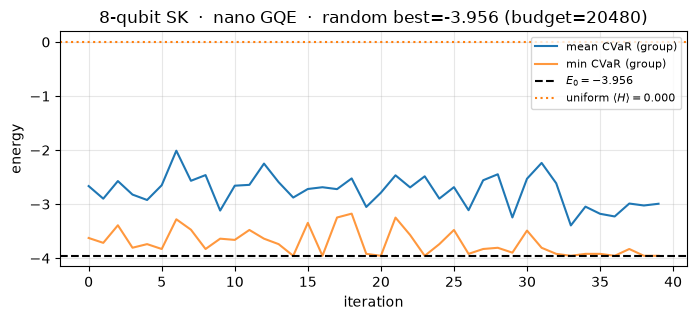

shot budget 20480 vs 2^n = 256
random sampler best energy = -3.9560   fraction of shots at E0 = 0.008
GQE best measured energy   = -3.9560   gap to E0 = 0.000e+00
best circuit: Y1(+0.79) Y7(+0.79) M(-0.20) C(0.40) M(+0.20) Y2(-0.79) M(-0.10) M(+0.20) M(-0.20) M(+0.10) M(-0.40) M(-0.10) ...


In [26]:
budget = ITERS_SK * GROUP_SK * SHOTS_SK
rand_idx = rng.integers(0, 2**N_SK, size=budget)
rand_best = float(energies_sk[rand_idx].min())
rand_hits = float(np.mean(energies_sk[rand_idx] <= E0_sk + 1e-12))

iters = [r["iter"] for r in hist_sk]
fig, ax = plt.subplots()
ax.plot(iters, [r["mean_score"] for r in hist_sk], label="mean CVaR (group)")
ax.plot(iters, [r["min_score"] for r in hist_sk], label="min CVaR (group)", alpha=0.8)
ax.axhline(E0_sk, color="k", ls="--", label=f"$E_0={E0_sk:.3f}$")
ax.axhline(energies_sk.mean(), color="C1", ls=":", label=f"uniform $\\langle H\\rangle={energies_sk.mean():.3f}$")
ax.set_xlabel("iteration")
ax.set_ylabel("energy")
ax.set_title(f"8-qubit SK  ·  nano GQE  ·  random best={rand_best:.3f} (budget={budget})")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"shot budget {budget} vs 2^n = {2**N_SK}")
print(f"random sampler best energy = {rand_best:.4f}   fraction of shots at E0 = {rand_hits:.3f}")
print(f"GQE best measured energy   = {best_sk['energy']:.4f}   gap to E0 = {best_sk['energy'] - E0_sk:.3e}")
print("best circuit:", " ".join(pool_sk[t].label for t in best_sk["tokens"][:12]), "...")


### Package check

Same instance, now trained with `gqe.train` (Catalyst-compiled `lightning.qubit`, GQE backbone). The first call compiles one program for this sequence length; after that each step is cheap. I kept the budget short so this cell stays under two minutes. If the inline numbers and the package numbers land in the same place, we can trust both.

In [27]:
from gqe import IsingProblem, TrainConfig, train as train_pkg

problem = IsingProblem(sk, cvar_alpha=ALPHA)
cfg = TrainConfig(
    n_iters=12,
    group_size=4,
    seq_len=8,
    shots=32,
    d_model=16,
    d_ff=32,
    n_layers=1,
    n_heads=4,
    policy_updates=4,
    backbone="gqe",
    seed=0,
)
print("compiling the Catalyst circuit (once), then 12 GRPO steps …")
res_pkg = train_pkg(problem, cfg)
print()
print(
    f"package GQE  best energy={res_pkg.best_energy:.4f}  "
    f"best CVaR={res_pkg.best_score:.4f}  params={res_pkg.n_params}  "
    f"shots used={res_pkg.shots_used}"
)
print(f"inline  GQE  best energy={best_sk['energy']:.4f}  best CVaR={best_sk['score']:.4f}")
print(f"exact E0                  {E0_sk:.4f}")


compiling the Catalyst circuit (once), then 12 GRPO steps …


gqe n=8: 100%|██████████| 12/12 [00:02<00:00,  5.37it/s]


package GQE  best energy=-3.9560  best CVaR=-3.8977  params=3131  shots used=1536
inline  GQE  best energy=-3.9560  best CVaR=-3.9560
exact E0                  -3.9560


## 7. Part 2: any Pauli-sum Hamiltonian (6-qubit TFIM)

Once \(H\) has off-diagonal terms, measured bitstrings aren't eigenstates anymore, so the QUBO trick (just keep the best shot) is dead. Instead the reward becomes the exact statevector energy \(\langle\psi\lvert H\rvert\psi\rangle\). On real hardware you'd estimate this by grouping shots into the Pauli bases that appear in \(H\). Here we have \(\lvert\psi\rangle\) in memory, so we just contract it.

Default instance: an open transverse-field Ising chain at the critical field,

\[
H = -\sum_{i=1}^{n-1} Z_i Z_{i+1} - g\sum_{i=1}^{n} X_i, \qquad g=1,\; n=6.
\]

Feel free to play: set `HAMILTONIAN` below to `"heisenberg"` (\(XX+YY+ZZ\) on each bond), or paste any `qml.Hamiltonian` under `"custom"`. We start from \(\lvert 0\rangle^{\otimes n}\).

In [28]:
HAMILTONIAN = "tfim"  # "tfim" | "heisenberg" | "custom"
N_GEN = 6
G_FIELD = 1.0


def make_tfim(n, g=1.0, periodic=False):
    coeffs, ops = [], []
    for i in range(n if periodic else n - 1):
        j = (i + 1) % n
        coeffs.append(-1.0)
        ops.append(qml.Z(i) @ qml.Z(j))
    for i in range(n):
        coeffs.append(-float(g))
        ops.append(qml.X(i))
    return qml.Hamiltonian(coeffs, ops)


def make_heisenberg(n, periodic=False):
    coeffs, ops = [], []
    for i in range(n if periodic else n - 1):
        j = (i + 1) % n
        for P in (qml.X, qml.Y, qml.Z):
            coeffs.append(1.0)
            ops.append(P(i) @ P(j))
    return qml.Hamiltonian(coeffs, ops)


if HAMILTONIAN == "tfim":
    H_gen = make_tfim(N_GEN, g=G_FIELD)
elif HAMILTONIAN == "heisenberg":
    H_gen = make_heisenberg(N_GEN)
else:
    # Replace this with any qml.Hamiltonian on N_GEN wires.
    H_gen = make_tfim(N_GEN, g=G_FIELD)

evals_gen, evecs_gen = exact_eigensystem(H_gen, N_GEN)
E0_gen = float(evals_gen[0])
psi_ground = evecs_gen[:, 0]
Hmat = np.asarray(qml.matrix(H_gen, wire_order=range(N_GEN)), dtype=np.complex128)

pool_gen = operator_pool(H_gen, N_GEN)
Us_gen = compile_unitaries(N_GEN, pool_gen)
psi0_gen = initial_statevector(N_GEN, "zero")
E_vac = float(np.real(np.vdot(np.asarray(psi0_gen), Hmat @ np.asarray(psi0_gen))))

print(f"{HAMILTONIAN}  n={N_GEN}  terms={len(H_gen.ops)}  |pool|={len(pool_gen)}")
print(f"E0={E0_gen:.4f}  <0|H|0>={E_vac:.4f}  gap={evals_gen[1] - evals_gen[0]:.4f}")


tfim  n=6  terms=11  |pool|=57
E0=-7.2962  <0|H|0>=-5.0000  gap=0.4821


In [29]:
def score_energy(seq, seed, unitaries=Us_gen, psi0=psi0_gen, H=Hmat, gs=psi_ground):
    del seed  # exact <H>; kept so the training loop's signature is shared
    psi = np.asarray(apply_tokens(jnp.asarray(seq, dtype=jnp.int32), unitaries, psi0))
    energy = float(np.real(np.vdot(psi, H @ psi)))
    fidelity = float(np.abs(np.vdot(gs, psi)) ** 2)
    return {"score": energy, "energy": energy, "fidelity": fidelity}


SEQ_GEN = 16
GROUP_GEN = 8
ITERS_GEN = 60

key, k_init = jax.random.split(key)
params_gen = init_transformer(
    k_init, vocab_size=len(pool_gen), max_len=SEQ_GEN, **{k: NANO[k] for k in ("d_model", "n_layers", "d_ff")}
)
print(f"nano GQE parameters: {count_params(params_gen)}")

params_gen, hist_gen, best_gen = train_gqe(
    key,
    params_gen,
    n_heads=NANO["n_heads"],
    score_fn=score_energy,
    n_iters=ITERS_GEN,
    group_size=GROUP_GEN,
    seq_len=SEQ_GEN,
    policy_updates=8,
    log_every=10,
)
key, _ = jax.random.split(key)
print(
    f"GQE  <H>={best_gen['energy']:.4f}  F={best_gen['fidelity']:.4f}  "
    f"gap to E0={best_gen['energy'] - E0_gen:.4f}"
)
print("best circuit:", " ".join(pool_gen[t].label for t in best_gen["tokens"]))


nano GQE parameters: 4249
  iter   0  mean=-2.9512  min=-4.8635  best=-4.8635  F=0.168
  iter  10  mean=-3.2530  min=-4.8296  best=-4.8703  F=0.167
  iter  20  mean=-3.2078  min=-4.8895  best=-5.9295  F=0.341
  iter  30  mean=-4.3952  min=-5.5775  best=-6.0318  F=0.341
  iter  40  mean=-4.8319  min=-5.4280  best=-6.0318  F=0.341
  iter  50  mean=-4.5165  min=-5.2993  best=-6.0562  F=0.311
  iter  59  mean=-4.8346  min=-5.3077  best=-6.0562  F=0.311
  done in 1.0s
GQE  <H>=-6.0562  F=0.3114  gap to E0=1.2401
best circuit: RX[1](+0.196) RZZ[1, 2](+0.196) RZZ[1, 2](+0.196) RZZ[1, 2](-0.196) Y2(+0.79) RZZ[2, 3](-0.196) RZZ[2, 3](+0.196) Y3(+0.79) RZZ[1, 2](+0.196) RZZ[1, 2](+0.196) RX[0](-0.196) RX[0](-0.196) Y5(+0.79) RZZ[1, 2](+0.196) RZZ[1, 2](-0.196) Y0(+0.79)


### VQE baseline, same \(H\)

For comparison: a 3-layer `StronglyEntanglingLayers` ansatz with **continuous** angles, trained by Adam on exact \(\langle H\rangle\). A gotcha I hit: small random inits collapse to \(\lvert 0\rangle\), which is a local minimum of this ansatz. A larger init lets the angles actually move. This is the opposite trade from GQE: VQE gets a smooth parametrization, GQE gets a combinatorial pool.

running 3-layer VQE …
VQE  params=54  <H>=-6.7651  gap to E0=0.5311


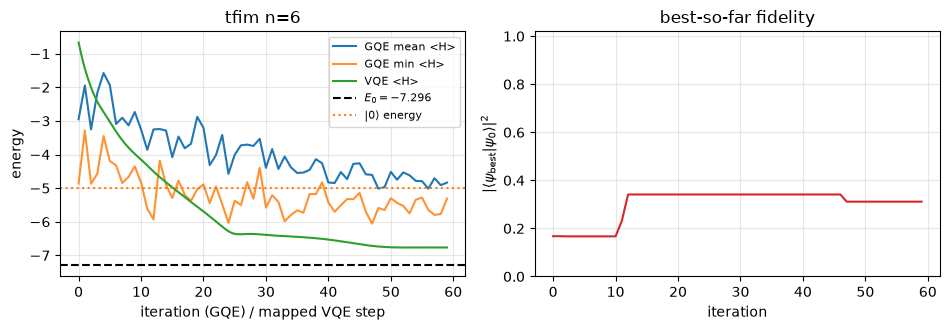

In [30]:
def vqe(H, n, n_layers=3, steps=180, lr=0.03, seed=0, scale=0.7):
    dev = qml.device("default.qubit", wires=n)
    shape = qml.StronglyEntanglingLayers.shape(n_layers, n)

    @qml.qnode(dev, interface="jax", diff_method="backprop")
    def circuit(weights):
        qml.StronglyEntanglingLayers(weights, wires=range(n))
        return qml.expval(H)

    w = scale * jax.random.normal(jax.random.PRNGKey(seed), shape, dtype=jnp.float64)
    opt = optax.adam(lr)
    opt_state = opt.init(w)

    @jax.jit
    def step(w, opt_state):
        e, g = jax.value_and_grad(circuit)(w)
        updates, opt_state = opt.update(g, opt_state)
        return optax.apply_updates(w, updates), opt_state, e

    hist = []
    for _ in range(steps):
        w, opt_state, e = step(w, opt_state)
        hist.append(float(e))
    return hist, w, int(np.prod(shape))


print("running 3-layer VQE …")
vqe_hist, _, n_vqe = vqe(H_gen, N_GEN)
print(f"VQE  params={n_vqe}  <H>={vqe_hist[-1]:.4f}  gap to E0={vqe_hist[-1] - E0_gen:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
it = [r["iter"] for r in hist_gen]
axes[0].plot(it, [r["mean_score"] for r in hist_gen], label="GQE mean <H>")
axes[0].plot(it, [r["min_score"] for r in hist_gen], label="GQE min <H>", alpha=0.85)
axes[0].plot(np.linspace(0, ITERS_GEN - 1, len(vqe_hist)), vqe_hist, label="VQE <H>", color="C2")
axes[0].axhline(E0_gen, color="k", ls="--", label=f"$E_0={E0_gen:.3f}$")
axes[0].axhline(E_vac, color="C1", ls=":", label=r"$|0\rangle$ energy")
axes[0].set_xlabel("iteration (GQE) / mapped VQE step")
axes[0].set_ylabel("energy")
axes[0].set_title(f"{HAMILTONIAN} n={N_GEN}")
axes[0].legend(fontsize=8)

axes[1].plot(it, [r.get("fidelity", np.nan) for r in hist_gen], color="C3")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel(r"$|\langle\psi_{\mathrm{best}}|\psi_0\rangle|^2$")
axes[1].set_ylim(0.0, 1.02)
axes[1].set_title("best-so-far fidelity")
plt.tight_layout()
plt.show()


## 8. Takeaways and knobs

**What grew, and what didn't.** The transformer is \(\mathcal{O}(\texttt{vocab}\times d + d^2)\) and stayed at ~5k weights the whole time. The quantum part is \(\mathcal{O}(2^n)\) statevectors here (or Catalyst-compiled sampling in the package). The pool grows like \(\#\{\text{Pauli terms}\}\times\#\{\text{angles}\} + 2n\) local RYs. That's exactly why the diagonal case uses *layer* tokens (one cost layer, not one `ZZ` per edge). A 20-token circuit of two-qubit gates simply can't move an \(n=14\) SK instance off the uniform distribution. Putting all of \(H\) into one token can. If you remember one thing from this notebook, make it this: the vocabulary matters more than the model.

**Knobs that actually matter**

| Knob | Effect |
|---|---|
| `seq_len` | Maximum circuit depth. Too short and the pool can't reach the ground state; too long and the useful tokens get diluted. |
| Angle grid | Discrete \(\gamma,\beta,\theta\). Coarser = smaller vocab, coarser ansatz. |
| `group_size` | GRPO's baseline. 4–8 is plenty at this scale. |
| `temperature` | Sampling entropy. 1.0 is a fine default; lower = greedier. |
| Reward | CVaR\(_\alpha\) (diagonal, shots) vs. exact \(\langle H\rangle\) (off-diagonal, statevector). \(\alpha\to 0\) is min-energy, \(\alpha=1\) is the mean. |

**Where to go next**

- Same loop, bigger diagonal instances: `gqe compare --profile laptop` (\(n=14\)) or `--profile nano` (\(n=16\)).
- On ASU Sol: `mkdir -p logs && sbatch examples/sol_nano.slurm`.
- Swap the MLP for HQKAN: `TrainConfig(backbone="gqkae")`. The implementation is in [`src/gqe/model.py`](../src/gqe/model.py).
- Want a new problem? Implement `Problem` (pool + `score` + `best_sample`). The trainer never looks inside it. See [`src/gqe/problem.py`](../src/gqe/problem.py).